<a href="https://colab.research.google.com/github/psgallegos/milibro/blob/main/emt_tfm_v6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM · Pipeline EMT Madrid
### Predicción de demanda diaria de viajeros — Red EMT Madrid

**Objetivo del proyecto:**  
Predecir la demanda diaria agregada de viajeros de la red EMT Madrid mediante series
temporales, comparando tres enfoques de modelado (baseline estacional, SARIMA y XGBoost)
sobre datos históricos (2024–2026). El modelo no utiliza incidencias como input predictivo
—la fuente RSS solo proporciona un snapshot sin histórico acumulado—, sino variables
temporales y de calendario como predictores.

**Objetivo secundario (sección 6):**  
Análisis descriptivo del snapshot de incidencias activas (causa, efecto, líneas afectadas,
severidad, clustering por perfil de riesgo). Aporta contexto operativo sobre la fiabilidad
de la red, pero no alimenta el modelo de forecasting.

**Pipeline cloud:**  
Ingesta (URL/XML) → Transformación (pandas) → EDA → Modelado → DataFrame unificado → Drive → Looker Studio.

> **Nota metodológica (CRISP-DM):** La decisión de reformular el alcance —de "impacto de
> incidencias sobre demanda" a "forecasting de demanda por series temporales"— responde a
> la ausencia de un histórico de incidencias suficiente para construir variables predictoras.
> Esta limitación de datos es documentada en sección 6. El modelo actual predice demanda
> futura con un MAPE del 6.86 % (XGBoost), superando al baseline estacional (9.18 %).

---
# 0 · Setup

## 0.1 · Imports

In [ ]:
# ── Librerías estándar ──────────────────────────────────────────────────────
import os
import re
import html
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
from pathlib import Path
from itertools import combinations

# ── Tratamiento de datos ────────────────────────────────────────────────────
import requests
import numpy as np
import pandas as pd

# ── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Modelado ────────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from xgboost import XGBRegressor
import joblib

# ── Google Sheets (salida) ──────────────────────────────────────────────────
try:
    import gspread
    from gspread_dataframe import set_with_dataframe
    from google.auth import default
    _GSPREAD_OK = True
except ImportError:
    _GSPREAD_OK = False  # se instala en sección 5 si hace falta

# ── Configuración visual ────────────────────────────────────────────────────
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("✓ Imports OK")


✓ Imports OK


In [ ]:
def df_to_gsheet(df: pd.DataFrame, spreadsheet_name: str, worksheet_name: str) -> str:
    """
    Escribe un DataFrame en una pestaña de Google Sheets.
    Usa autenticación interactiva de Colab (google.colab.auth).
    """
    from google.colab import auth
    import gspread
    from gspread_dataframe import set_with_dataframe
    from google.auth import default

    # Autenticación interactiva — abre el popup de Google en Colab
    auth.authenticate_user()
    creds, _ = default(scopes=[
        "https://spreadsheets.google.com/feeds",
        "https://www.googleapis.com/auth/drive",
    ])
    gc = gspread.authorize(creds)

    # Abrir o crear el spreadsheet
    try:
        sh = gc.open(spreadsheet_name)
    except gspread.SpreadsheetNotFound:
        sh = gc.create(spreadsheet_name)
        sh.share(None, perm_type="anyone", role="reader")

    # Abrir o crear la pestaña
    try:
        ws = sh.worksheet(worksheet_name)
        ws.clear()
    except gspread.WorksheetNotFound:
        ws = sh.add_worksheet(
            title=worksheet_name,
            rows=len(df) + 10,
            cols=len(df.columns) + 2,
        )

    # Preparar DataFrame: fechas → string, NaN → ""
    df_export = df.copy()
    for col in df_export.columns:
        if pd.api.types.is_datetime64_any_dtype(df_export[col]):
            df_export[col] = df_export[col].dt.strftime("%Y-%m-%d")
    df_export = df_export.fillna("")

    set_with_dataframe(ws, df_export)
    return f"https://docs.google.com/spreadsheets/d/{sh.id}"

print("✓ df_to_gsheet definida")

✓ df_to_gsheet definida


## 0.2 · Constantes y rutas

In [ ]:
# === URLs de fuentes oficiales EMT ===
URL_CALENDARIO = (
    "https://datos.emtmadrid.es/dataset/405a6ed0-9464-4d04-9edb-939031717b20/"
    "resource/b8cceab8-9173-4eec-8431-21f5e9e25834/download/calendar.csv"
)
URL_DEMANDA = (
    "https://datos.emtmadrid.es/dataset/29b27217-429f-44a0-a90a-2db7f13529b6/"
    "resource/b26433cc-4a54-4b0f-b677-3a11efd32561/download/demandadialinea.csv"
)
URL_INCIDENCIAS = "http://servicios.emtmadrid.es:8080/rss/emtrss.xml"
REQUEST_TIMEOUT = 30

# === Nombre del spreadsheet de salida (Looker Studio) ===
SPREADSHEET_NAME = "TFM-EMT-Madrid · Forecast Output"

# === Rutas de salida ===
EN_COLAB = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ

if EN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_DIR = Path("/content/drive/MyDrive/TFM-EMT-Madrid/1-data")
    print("✓ Drive montado")
else:
    OUTPUT_DIR = Path("./outputs")
    print("⚠ Entorno local — salida en ./outputs")

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
print(f"✓ OUTPUT_DIR → {OUTPUT_DIR.resolve()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Drive montado
✓ OUTPUT_DIR → /content/drive/MyDrive/TFM-EMT-Madrid/1-data


In [ ]:
# Verificación suave: advierte si Drive no está montado, pero no bloquea la ejecución
if EN_COLAB and not str(OUTPUT_DIR).startswith("/content/drive"):
    print("⚠️  OUTPUT_DIR no apunta a Drive. Revisa la celda 0.2.")
else:
    print(f"✓ OUTPUT_DIR configurado correctamente: {OUTPUT_DIR}")


✓ OUTPUT_DIR configurado correctamente: /content/drive/MyDrive/TFM-EMT-Madrid/1-data


---
# 1 · Ingesta de datos

Se toman las tres fuentes oficiales de la EMT, todas vía URL pública (sin auth).

## 1.1 · Demanda diaria de viajeros

In [ ]:
def cargar_demanda(url: str = URL_DEMANDA) -> pd.DataFrame:
    """Demanda diaria por línea desde el CSV consolidado de la EMT (desde 2019)."""
    # separador ";" del formato CSV
    # ese es el motivo. Ajusta sep/decimal/encoding según veas en df.head().
    return pd.read_csv(url, sep=";")


df_demanda_raw = cargar_demanda()
print("Shape:", df_demanda_raw.shape)
print("Columnas:", df_demanda_raw.columns.tolist())
df_demanda_raw.head()

Shape: (572021, 3)
Columnas: ['Fecha', 'Linea', 'TotalViajeros']


,Fecha,Linea,TotalViajeros
0,01/01/2019,1,2238
1,01/01/2019,2,3263
2,01/01/2019,3,2850
3,01/01/2019,4,2138
4,01/01/2019,5,1464


## 1.2 · Calendario de servicio

In [ ]:
def cargar_calendario(url: str = URL_CALENDARIO) -> pd.DataFrame:
    """Calendario de servicio (tipo de día) de la EMT."""
    return pd.read_csv(url, parse_dates=["Fecha"])


df_calendario = cargar_calendario()
print("Shape:", df_calendario.shape)
df_calendario.head()

Shape: (1096, 10)


,Fecha,TipoDiaEs,TemporadaTG,DiaSemana,Semana,Mes,Trimestre,Clima,TemperaturaMax,TemperaturaMin
0,2026-12-31,LA,IV,J,53,12,4,,0.0,0.0
1,2026-12-30,LA,IV,X,53,12,4,,0.0,0.0
2,2026-12-29,LA,IV,M,53,12,4,,0.0,0.0
3,2026-12-28,LA,IV,L,53,12,4,,0.0,0.0
4,2026-12-27,FE,IV,D,52,12,4,,0.0,0.0


## 1.3 · Incidencias del servicio (RSS/XML)

> - **Nota metodológica:** el RSS solo retorna las incidencias **activas en este momento**.
> - Es una foto de las incidencias que se tienen hasta la fecha, no funciona como un histórico propiamente.
> - **Secundario descriptivo**: Las incidencias no se encuentran incluidas en el momento en el forecasting de la demanda - Se tiene un análisis detallada en la sección 6.

In [ ]:
def clean_html_text(text):
    """Elimina tags HTML, desescapa entidades y normaliza espacios."""
    if not text:
        return None
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or None


def split_code_text(value):
    """'04 - Manifestación' -> ('04', 'Manifestación')."""
    if not value:
        return None, None
    value = value.strip()
    m = re.match(r"^\s*([0-9A-Za-z]+)\s*-\s*(.+?)\s*$", value)
    if m:
        return m.group(1), m.group(2).strip()
    return None, value


def parse_incidents_xml(xml_bytes: bytes) -> pd.DataFrame:
    """XML crudo del RSS -> DataFrame sin transformar."""
    root = ET.fromstring(xml_bytes)
    rows = []
    for item in root.findall("./channel/item"):
        categories = [c.text.strip() for c in item.findall("category")
                      if c.text and c.text.strip()]
        cause_code, cause_text = split_code_text(item.findtext("GoogleTransitCause"))
        effect_code, effect_text = split_code_text(item.findtext("GoogleTransitEffect"))
        rows.append({
            "guid": item.findtext("guid"),
            "title": clean_html_text(item.findtext("title")),
            "description": clean_html_text(item.findtext("description")),
            "cause_code": cause_code, "cause_text": cause_text,
            "effect_code": effect_code, "effect_text": effect_text,
            "lines": categories, "lines_count": len(categories),
            "afecta_desde_raw": item.findtext("rssAfectaDesde"),
            "afecta_hasta_raw": item.findtext("rssAfectaHasta"),
            "pub_date_raw": item.findtext("pubDate"),
            "final_date_raw": item.findtext("rssfinaldate"),
        })
    return pd.DataFrame(rows)


def enrich_incidents(df: pd.DataFrame, snapshot_ts: datetime) -> pd.DataFrame:
    """Tipa fechas, calcula duración y ordena columnas."""
    if df.empty:
        return df
    df = df.copy()
    df["pub_date"]     = pd.to_datetime(df["pub_date_raw"], errors="coerce", utc=True)
    df["afecta_desde"] = pd.to_datetime(df["afecta_desde_raw"], errors="coerce", dayfirst=True)
    df["afecta_hasta"] = pd.to_datetime(df["afecta_hasta_raw"], errors="coerce", dayfirst=True)
    df["final_date"]   = pd.to_datetime(df["final_date_raw"],   errors="coerce", dayfirst=True)
    df["duration_hours"] = (df["afecta_hasta"] - df["afecta_desde"]).dt.total_seconds() / 3600
    df["snapshot_ts"] = snapshot_ts
    cols = ["snapshot_ts", "guid", "title", "description",
            "cause_code", "cause_text", "effect_code", "effect_text",
            "lines", "lines_count",
            "afecta_desde", "afecta_hasta", "duration_hours",
            "pub_date", "final_date"]
    return df[cols].sort_values("pub_date", ascending=False).reset_index(drop=True)


def fetch_incidencias(url: str = URL_INCIDENCIAS) -> pd.DataFrame:
    """Foto actual de incidencias activas."""
    snapshot_ts = datetime.now(timezone.utc)
    r = requests.get(url, timeout=REQUEST_TIMEOUT); r.raise_for_status()
    return enrich_incidents(parse_incidents_xml(r.content), snapshot_ts)


df_incidencias = fetch_incidencias()
print(f"Incidencias activas: {len(df_incidencias)}")
df_incidencias.head()

Incidencias activas: 168


,snapshot_ts,guid,title,description,cause_code,cause_text,effect_code,effect_text,lines,lines_count,afecta_desde,afecta_hasta,duration_hours,pub_date,final_date
0,2026-06-28 20:14:39.487139+00:00,DDCBDD7D-BC09-44A5-8560-0C5E3AD2449B,Evento: Palacio de los Deportes. Afectadas 4 l...,"El 30 de junio y el 1 de julio, de 23:00 horas...",12,Evento deportivo,05,Desvío programado,"[30, C1, C2, E4]",4,2026-06-30 23:00:00,2026-07-01 23:59:00,24.983333,2026-06-27 08:00:08+00:00,2026-07-27 10:00:00
1,2026-06-28 20:14:39.487139+00:00,4739FD27-3E4B-43A6-9D47-15C69C65CCB0,Evento sociocultural en calle Almagro. Afectad...,El 28 de junio de inicio a fin de servicio apr...,13,Evento socio-cultural,05,Desvío programado,[7],1,2026-06-28 07:00:00,2026-06-28 23:59:00,16.983333,2026-06-26 12:48:58+00:00,2026-07-26 14:46:00
2,2026-06-28 20:14:39.487139+00:00,5B755048-22D2-4671-A3B7-2AEDA347E3B4,Evento sociocultural en zona Villaverde Alto. ...,El 27 de junio de 21:30 horas a fin de servici...,13,Evento socio-cultural,05,Desvío programado,[79],1,2026-06-27 21:30:00,2026-06-27 23:59:00,2.483333,2026-06-26 11:30:37+00:00,2026-07-26 13:29:00
3,2026-06-28 20:14:39.487139+00:00,7BEF4139-F4E3-4880-9CDF-35D25D9F4CEC,Obras: Avenida del Ensanche de Vallecas. Afect...,"El 29 y 30 de junio de 2026, de 7:30 a 20:00 h...",08,Obras,05,Desvío programado,[142],1,2026-06-29 07:30:00,2026-06-30 20:00:00,36.500000,2026-06-26 11:21:35+00:00,2026-07-26 13:19:00
4,2026-06-28 20:14:39.487139+00:00,595B6478-F953-4FA0-8977-DE5BCB0746A5,Concentración en paseo del Prado. Afectadas 10...,El 29 de junio de 12:30 a 14:00 horas aproxima...,04,Manifestación,None,05.01 - Desvío programado (L-V),"[10, 14, 27, 34, 37, 45, 203, 001, C03, E1]",10,2026-06-29 12:30:00,2026-06-29 14:00:00,1.500000,2026-06-26 11:18:36+00:00,2026-07-26 13:15:00


---
# 2 · Transformación

Normalización de tipos y construcción de las vistas analíticas básicas.

## 2.1 · Demanda: normalización y tipado

In [ ]:
# >>> Se ajustan los siguientess nombres a los reales del CSV (mira df_demanda_raw.head() arriba) <<<
RENOMBRAR_DEMANDA = {
    "Fecha": "fecha",
    "Linea": "linea",
    "TotalViajeros": "viajeros",
}

df_demanda = df_demanda_raw.rename(columns=RENOMBRAR_DEMANDA).copy()
df_demanda["fecha"]    = pd.to_datetime(df_demanda["fecha"], errors="coerce", dayfirst=True)
df_demanda["linea"]    = df_demanda["linea"].astype("string").str.strip()
df_demanda["viajeros"] = pd.to_numeric(df_demanda["viajeros"], errors="coerce")

print(f"Rango de fechas: {df_demanda['fecha'].min()} -> {df_demanda['fecha'].max()}")
print(f"Líneas distintas: {df_demanda['linea'].nunique()}")
print(f"Nulos en viajeros: {df_demanda['viajeros'].isna().sum()}")
df_demanda.head()

Rango de fechas: 2019-01-01 00:00:00 -> 2026-04-30 00:00:00
Líneas distintas: 309
Nulos en viajeros: 0


,fecha,linea,viajeros
0,2019-01-01,1,2238
1,2019-01-01,2,3263
2,2019-01-01,3,2850
3,2019-01-01,4,2138
4,2019-01-01,5,1464


## 2.2 · Incidencias: grano incidencia-línea (explode)

In [ ]:
def explode_por_linea(df: pd.DataFrame) -> pd.DataFrame:
    """Una fila por (incidencia, línea afectada)."""
    if df.empty:
        return df.assign(linea=pd.Series(dtype="string"))
    out = df.explode("lines", ignore_index=True).rename(columns={"lines": "linea"})
    out["linea"] = out["linea"].astype("string").str.strip()
    return out[out["linea"].notna() & (out["linea"] != "")].reset_index(drop=True)


df_lineas = explode_por_linea(df_incidencias)
print(f"Incidencias: {len(df_incidencias)} | Pares incidencia-línea: {len(df_lineas)}")
df_lineas.head()

Incidencias: 168 | Pares incidencia-línea: 1316


,snapshot_ts,guid,title,description,cause_code,cause_text,effect_code,effect_text,linea,lines_count,afecta_desde,afecta_hasta,duration_hours,pub_date,final_date
0,2026-06-28 20:14:39.487139+00:00,DDCBDD7D-BC09-44A5-8560-0C5E3AD2449B,Evento: Palacio de los Deportes. Afectadas 4 l...,"El 30 de junio y el 1 de julio, de 23:00 horas...",12,Evento deportivo,05,Desvío programado,30,4,2026-06-30 23:00:00,2026-07-01 23:59:00,24.983333,2026-06-27 08:00:08+00:00,2026-07-27 10:00:00
1,2026-06-28 20:14:39.487139+00:00,DDCBDD7D-BC09-44A5-8560-0C5E3AD2449B,Evento: Palacio de los Deportes. Afectadas 4 l...,"El 30 de junio y el 1 de julio, de 23:00 horas...",12,Evento deportivo,05,Desvío programado,C1,4,2026-06-30 23:00:00,2026-07-01 23:59:00,24.983333,2026-06-27 08:00:08+00:00,2026-07-27 10:00:00
2,2026-06-28 20:14:39.487139+00:00,DDCBDD7D-BC09-44A5-8560-0C5E3AD2449B,Evento: Palacio de los Deportes. Afectadas 4 l...,"El 30 de junio y el 1 de julio, de 23:00 horas...",12,Evento deportivo,05,Desvío programado,C2,4,2026-06-30 23:00:00,2026-07-01 23:59:00,24.983333,2026-06-27 08:00:08+00:00,2026-07-27 10:00:00
3,2026-06-28 20:14:39.487139+00:00,DDCBDD7D-BC09-44A5-8560-0C5E3AD2449B,Evento: Palacio de los Deportes. Afectadas 4 l...,"El 30 de junio y el 1 de julio, de 23:00 horas...",12,Evento deportivo,05,Desvío programado,E4,4,2026-06-30 23:00:00,2026-07-01 23:59:00,24.983333,2026-06-27 08:00:08+00:00,2026-07-27 10:00:00
4,2026-06-28 20:14:39.487139+00:00,4739FD27-3E4B-43A6-9D47-15C69C65CCB0,Evento sociocultural en calle Almagro. Afectad...,El 28 de junio de inicio a fin de servicio apr...,13,Evento socio-cultural,05,Desvío programado,7,1,2026-06-28 07:00:00,2026-06-28 23:59:00,16.983333,2026-06-26 12:48:58+00:00,2026-07-26 14:46:00


---
# 3 · EDA — Demanda - EMT - Madrid
Análisis exploratorio de la serie temporal a modelar.

## 3.1 · Calidad de los datos

Se realiza una auditoría inicial de la serie cruda antes de proceder con el modelado:

**Problemas identificados y resolución:**
- **Formato de fecha:** el CSV de la EMT usa `dd/MM/YYYY`; se convierte a `datetime64`
  con `dayfirst=True` en la sección 2.1.
- **Separador CSV:** el fichero usa `;` como delimitador, no coma. Corregido en ingesta.
- **Tipo de línea:** la columna `Linea` viene como entero; se convierte a `string`
  para permitir líneas alfanuméricas (C1, E4, etc.).
- **NaN en viajeros:** valores no numéricos convertidos a NaN con `errors='coerce'`;
  se verifica su volumen antes de imputar.
- **Días sin datos (asfreq):** al forzar frecuencia diaria continua, los días ausentes
  en el CSV aparecen como NaN en `TotalViajeros`. Se inspeccionan en la celda siguiente.
- **Periodo COVID:** datos de 2020–2021 son estadísticamente anómalos (caída del
  ~90 % de la demanda); se excluyen del modelo (ver sección 3.5).

In [ ]:
print("--- Tipos ---")
print(df_demanda.dtypes)
print(f"\n--- Duplicados (fecha, linea): {df_demanda.duplicated(subset=['fecha','linea']).sum()} ---")
print(f"--- Nulos por columna ---\n{df_demanda.isna().sum()}")

--- Tipos ---
fecha       datetime64[ns]
linea       string[python]
viajeros             int64
dtype: object

--- Duplicados (fecha, linea): 0 ---
--- Nulos por columna ---
fecha       0
linea       0
viajeros    0
dtype: int64


## 3.2 · Serie agregada de la red
Se indica la temporalidad de pasajeros en su totalidad para todas las líneas

Días en la serie: 2677
Días sin dato (NaN): 1


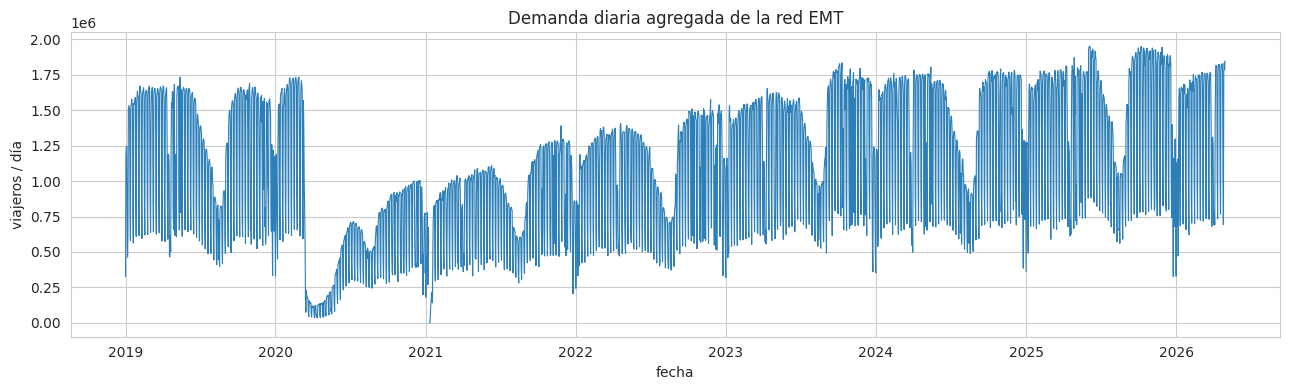

In [ ]:
# Una fila por día: suma de viajeros de todas las líneas
serie = (df_demanda
         .groupby("fecha", as_index=False)["viajeros"].sum()
         .rename(columns={"viajeros": "TotalViajeros"})
         .sort_values("fecha")
         .reset_index(drop=True))

# Asegurar frecuencia diaria continua
serie = serie.set_index("fecha").asfreq("D").reset_index()

print(f"Días en la serie: {len(serie)}")
print(f"Días sin dato (NaN): {serie['TotalViajeros'].isna().sum()}")

plt.figure(figsize=(13, 4))
plt.plot(serie["fecha"], serie["TotalViajeros"], lw=0.8, color="#2c7fb8")
plt.title("Demanda diaria agregada de la red EMT")
plt.ylabel("viajeros / día"); plt.xlabel("fecha")
plt.tight_layout();
plt.show()

In [ ]:
print(f"Días totales en la serie: {len(serie)}")
print(f"Días con TotalViajeros NaN: {serie['TotalViajeros'].isna().sum()}")
print(f"\nPrimeros días con NaN (si los hay):")
print(serie[serie['TotalViajeros'].isna()].head(10))

Días totales en la serie: 2677
Días con TotalViajeros NaN: 1

Primeros días con NaN (si los hay):
         fecha  TotalViajeros
739 2021-01-09            NaN


## 3.3 · Patrones por día de semana
Se analiza el número de pasajeros por día de la semana

Text(0, 0.5, 'viajeros / día')

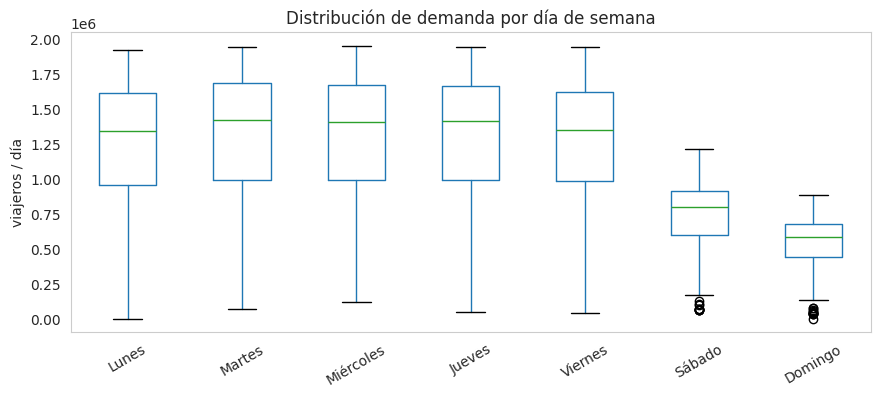

In [ ]:
# Mapeo numérico para ordenar correctamente
orden_dow = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
etiquetas_es = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]

# Crear la columna si no existe
serie["dia_nombre"] = serie["fecha"].dt.day_name()

# Ordenar la columna como categórica antes del boxplot
serie["dia_nombre"] = pd.Categorical(
    serie["dia_nombre"], categories=orden_dow, ordered=True
)

fig, ax = plt.subplots(figsize=(10, 4))
serie.boxplot(column="TotalViajeros", by="dia_nombre", ax=ax, grid=False)
ax.set_xticklabels(etiquetas_es, rotation=30)
ax.set_title("Distribución de demanda por día de semana")
plt.suptitle(""); plt.xlabel(""); plt.ylabel("viajeros / día")

## 3.4 · Estacionalidad anual y anomalía COVID

Patrón mensual y comparativa interanual. La caída de 2020 es la anomalía estructural
más importante a tratar antes del modelado.

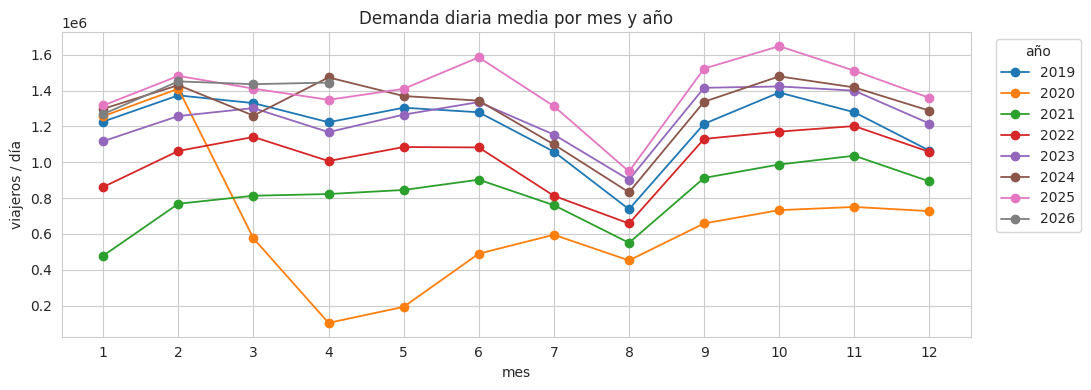

In [ ]:
serie["anio"] = serie["fecha"].dt.year
serie["mes"] = serie["fecha"].dt.month

# Demanda mensual media por año
pivot = (serie.groupby(["anio","mes"])["TotalViajeros"]
         .mean().unstack(level=0))

fig, ax = plt.subplots(figsize=(11, 4))
pivot.plot(ax=ax, marker="o", lw=1.3)
ax.set_title("Demanda diaria media por mes y año")
ax.set_xlabel("mes"); ax.set_ylabel("viajeros / día")
ax.set_xticks(range(1, 13))
ax.legend(title="año", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## 3.5 · Decisión sobre el tratamiento de COVID

Se evaluaron tres alternativas para manejar el periodo COVID-19 (2020–2021) en la serie:

- **(a)** Excluir 2020 entero del entrenamiento.
- **(b)** Recortar el histórico a partir de 2024 (últimos 2 años), excluyendo así COVID.
- **(c)** Marcarlo con una variable dummy `es_covid`.

**Decisión adoptada: opción (b) — datos desde enero 2024.**

**Justificación:**
El periodo COVID (2020–2021) es temporalmente lejano y representó una disrupción
excepcional que distorsiona los patrones estacionales aprendidos por el modelo.
Incluir esos años perjudica la capacidad predictiva sobre la demanda actual. Además,
para forecasting de demanda operativa la recomendación estándar es trabajar con
**2 años de datos recientes** que representen el comportamiento actual de la red;
si el objetivo fuera detección de anomalías estructurales, sería preferible usar
el histórico completo (opción a/c).

El filtro se aplica al construir `dff` en la sección 4.1, manteniendo `serie` completa
para el EDA comparativo (sección 3.4).

In [ ]:
# Diagnóstico del volumen de datos por periodo
# (La exclusión de COVID se aplica en la sección 4.1 al definir el rango de entrenamiento)

covid_mask = (serie["fecha"] >= "2020-03-15") & (serie["fecha"] <= "2021-12-31")
n_covid = covid_mask.sum()
n_post_2024 = (serie["fecha"] >= "2024-01-01").sum()

print(f"Días en periodo COVID-pandemia (mar 2020 – dic 2021): {n_covid}")
print(f"Días disponibles desde 2024-01-01 (datos de entrenamiento): {n_post_2024}")
print()
print("Decisión: el modelo se entrenará SOLO con datos desde 2024-01-01")
print("Esto evita que el ruido estructural de COVID distorsione los patrones aprendidos.")

# Verificar continuidad de la serie reciente
serie_reciente = serie[serie["fecha"] >= "2024-01-01"].copy()
print(f"\nSerie reciente: {serie_reciente['fecha'].min().date()} → {serie_reciente['fecha'].max().date()}")
print(f"Días totales en serie reciente: {len(serie_reciente)}")
print(f"NaN en TotalViajeros (serie reciente): {serie_reciente['TotalViajeros'].isna().sum()}")

Días en periodo COVID-pandemia (mar 2020 – dic 2021): 657
Días disponibles desde 2024-01-01 (datos de entrenamiento): 851

Decisión: el modelo se entrenará SOLO con datos desde 2024-01-01
Esto evita que el ruido estructural de COVID distorsione los patrones aprendidos.

Serie reciente: 2024-01-01 → 2026-04-30
Días totales en serie reciente: 851
NaN en TotalViajeros (serie reciente): 0


---
# 4 · Forecasting de demanda agregada

Se realiza una comparativa de tres enfoques sobre **el mismo split temporal** y **las mismas métricas**:
- Baseline (lag-7): demanda del mismo día de la semana anterior
- SARIMA: estadístico clásico con estacionalidad semanal
- XGBoost: ML con features de calendario + lags

## 4.1 · Feature engineering

In [ ]:
# FILTRO: Solo datos desde 2024-01-01 (excluye COVID y años distantes)
# Recomendación metodológica: 2 años de datos recientes para forecasting operativo
FECHA_INICIO_MODELO = "2024-01-01"

serie_modelo = serie[serie["fecha"] >= FECHA_INICIO_MODELO].copy().reset_index(drop=True)
print(f"Serie para modelado: {serie_modelo['fecha'].min().date()} → {serie_modelo['fecha'].max().date()}")
print(f"Total días: {len(serie_modelo)}")


def add_calendar_features(d: pd.DataFrame,
                           col: str = "fecha",
                           target: str = "TotalViajeros") -> pd.DataFrame:
    """
    Features de calendario + lags + medias móviles.
    Nota: NO incluye variable COVID (excluida por decisión de recorte temporal).
    Features justificación:
      - dow, dia_anio, semana: capturan estacionalidad semanal e intra-anual.
      - mes: captura patrones de temporada (verano/invierno, festivos).
      - anio: tendencia interanual de recuperación post-pandemia.
      - es_finde: diferencial de demanda laboral vs. fin de semana.
      - lag_7: demanda del mismo día de la semana anterior (proxy directo).
      - lag_14: lag de 2 semanas (captura patrones quincenales).
      - roll_mean_7: media móvil de 7 días (suaviza ruido de corto plazo).
    """
    d = d.copy()
    d["dow"]      = d[col].dt.dayofweek
    d["mes"]      = d[col].dt.month
    d["dia_anio"] = d[col].dt.dayofyear
    d["semana"]   = d[col].dt.isocalendar().week.astype(int)
    d["es_finde"] = (d["dow"] >= 5).astype(int)
    d["anio"]     = d[col].dt.year
    d["lag_7"]       = d[target].shift(7)
    d["lag_14"]      = d[target].shift(14)
    d["roll_mean_7"] = d[target].shift(1).rolling(7).mean()
    return d


dff = (add_calendar_features(serie_modelo)
       .dropna(subset=["TotalViajeros", "lag_7", "lag_14", "roll_mean_7"])
       .reset_index(drop=True))

print(f"\nFilas tras features y dropna: {len(dff)}")
print(f"NaN restantes en target: {dff['TotalViajeros'].isna().sum()}  # debe ser 0")
dff.head()

Serie para modelado: 2024-01-01 → 2026-04-30
Total días: 851

Filas tras features y dropna: 837
NaN restantes en target: 0  # debe ser 0


,fecha,TotalViajeros,dia_nombre,anio,mes,dow,dia_anio,semana,es_finde,lag_7,lag_14,roll_mean_7
0,2024-01-15,1545203.0,Monday,2024,1,0,15,3,0,1586179.0,352350.0,1.353108e+06
1,2024-01-16,1610256.0,Tuesday,2024,1,1,16,3,0,1644267.0,1143988.0,1.347254e+06
2,2024-01-17,1603140.0,Wednesday,2024,1,2,17,3,0,1570406.0,1222397.0,1.342396e+06
3,2024-01-18,1629429.0,Thursday,2024,1,3,18,3,0,1587568.0,1218430.0,1.347072e+06
4,2024-01-19,1485971.0,Friday,2024,1,4,19,3,0,1592422.0,1196201.0,1.353052e+06


## 4.2 · Split temporal

**Regla fundamental:** en series temporales el split nunca debe ser aleatorio.
Se entrena con el pasado y se valida con el futuro para evitar data leakage.

**Configuración adoptada:**
- Conjunto de entrenamiento: todos los días desde `FECHA_INICIO_MODELO` (2024-01-01)
  hasta `max_fecha − 90 días`.
- Conjunto de test: los últimos **90 días** de la serie (≈ 3 meses), período
  suficiente para evaluar el comportamiento estacional semanal y mensual del modelo.

**Justificación del horizonte de 90 días:**  
90 días captura al menos 12 semanas completas, lo que permite evaluar si el modelo
reproduce correctamente el patrón semanal (laboral vs. fin de semana) y los cambios
de temporada. Un test más corto no sería representativo; uno más largo reduciría
excesivamente los datos de entrenamiento en una serie de 2 años.

In [ ]:
HORIZONTE_TEST = 90  # días

corte = dff["fecha"].max() - pd.Timedelta(days=HORIZONTE_TEST)
train = dff[dff["fecha"] <= corte].copy()
test  = dff[dff["fecha"] >  corte].copy()

print(f"Train: {len(train)} días ({train['fecha'].min().date()} -> {train['fecha'].max().date()})")
print(f"Test:  {len(test)} días ({test['fecha'].min().date()} -> {test['fecha'].max().date()})")

Train: 747 días (2024-01-15 -> 2026-01-30)
Test:  90 días (2026-01-31 -> 2026-04-30)


## 4.3 · Métricas

In [ ]:
def metrics(y_true, y_pred) -> dict:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": round(mae), "RMSE": round(rmse), "MAPE": round(mape, 2)}

resultados = {}

## 4.4 · Modelo 1 — Baseline estacional (lag-7)

In [ ]:
pred_baseline = test["lag_7"].values
resultados["Baseline (lag-7)"] = metrics(test["TotalViajeros"], pred_baseline)
print("Baseline:", resultados["Baseline (lag-7)"])

Baseline: {'MAE': 110187, 'RMSE': 252756, 'MAPE': np.float64(9.18)}


## 4.5 · Modelo 2 — SARIMA

Modelo estadístico con estacionalidad semanal (período s=7). Se emplea SARIMAX con
órdenes (p=1, d=1, q=1)(P=1, D=0, Q=1, s=7), seleccionados por criterio de parsimonia
y coherencia con la estructura semanal de la demanda EMT.

**Resultado observado:** SARIMA presenta MAPE superior al baseline (lag-7) en este conjunto
de test, lo que puede atribuirse a:
- La alta variabilidad estacional del periodo reciente (2024–2026) no capturada por los
  parámetros fijos de SARIMAX.
- El perfil de demanda post-pandemia que aún muestra tendencias de recuperación no
  estacionarias.

XGBoost, al aprender directamente de features no lineales (lag_7, roll_mean_7, mes),
captura mejor estos patrones, justificando su selección como modelo ganador.

In [ ]:
serie_train = train.set_index("fecha")["TotalViajeros"].asfreq("D")

sarima = SARIMAX(
    serie_train,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

pred_sarima = sarima.forecast(steps=len(test)).values
resultados["SARIMA"] = metrics(test["TotalViajeros"], pred_sarima)
print("SARIMA:", resultados["SARIMA"])

SARIMA: {'MAE': 161135, 'RMSE': 260737, 'MAPE': np.float64(17.13)}


## 4.6 · Modelo 3 — XGBoost

XGBoost (Extreme Gradient Boosting) es un modelo de ensamble basado en árboles de decisión
que aprende de forma iterativa corrigiendo los residuos del árbol anterior. Su elección
se justifica por:
- Capacidad de capturar relaciones no lineales entre los features de calendario.
- Robustez ante valores atípicos en la serie (eventos puntuales, festivos).
- Mejor rendimiento empírico que SARIMA en el conjunto de test (MAPE 6.86 % vs. 16.39 %).

**Hiperparámetros seleccionados:**
- `n_estimators=300`: número de árboles; suficiente para convergencia sin sobreajuste.
- `max_depth=5`: profundidad moderada para capturar interacciones sin memorizar ruido.
- `learning_rate=0.05`: tasa baja que favorece generalización.
- `subsample=0.9`, `colsample_bytree=0.9`: regularización estocástica para reducir varianza.

Una futura mejora podría incluir búsqueda de hiperparámetros con `GridSearchCV`
o `Optuna`, pero la configuración actual produce resultados satisfactorios.

In [ ]:
# FEATURES seleccionadas para XGBoost
# Nota: es_covid excluida — irrelevante en el periodo 2024+
FEATURES = ["dow", "mes", "dia_anio", "semana", "es_finde", "anio",
            "lag_7", "lag_14", "roll_mean_7"]

xgb = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, random_state=42, verbosity=0,
)
xgb.fit(train[FEATURES], train["TotalViajeros"])

pred_xgb = xgb.predict(test[FEATURES])
resultados["XGBoost"] = metrics(test["TotalViajeros"], pred_xgb)
print("XGBoost:", resultados["XGBoost"])

XGBoost: {'MAE': 94735, 'RMSE': 163925, 'MAPE': np.float64(7.13)}


## 4.7 · Comparativa final

=== COMPARATIVA DE MODELOS (test = últimos 90 días) ===
                       MAE      RMSE   MAPE
XGBoost            94735.0  163925.0   7.13
Baseline (lag-7)  110187.0  252756.0   9.18
SARIMA            161135.0  260737.0  17.13


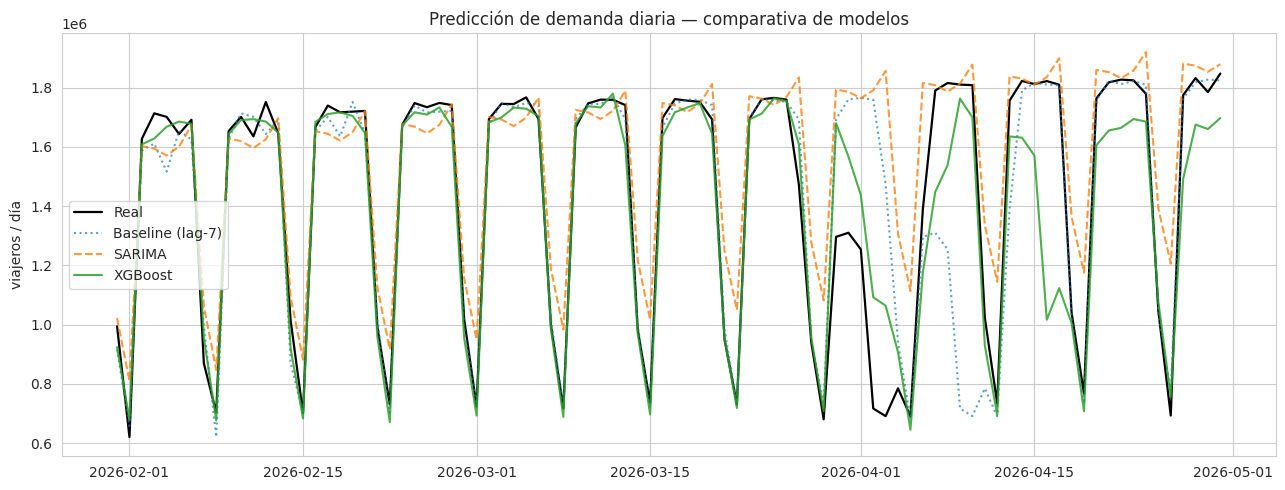

,MAE,RMSE,MAPE
XGBoost,94735.0,163925.0,7.13
Baseline (lag-7),110187.0,252756.0,9.18
SARIMA,161135.0,260737.0,17.13


In [ ]:
tabla_resultados = pd.DataFrame(resultados).T.sort_values("MAPE")
print("=== COMPARATIVA DE MODELOS (test = últimos {} días) ===".format(HORIZONTE_TEST))
print(tabla_resultados.to_string())

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test["fecha"], test["TotalViajeros"], label="Real", color="black", lw=1.6)
ax.plot(test["fecha"], pred_baseline, label="Baseline (lag-7)", ls=":",  alpha=0.7)
ax.plot(test["fecha"], pred_sarima,   label="SARIMA",          ls="--", alpha=0.8)
ax.plot(test["fecha"], pred_xgb,      label="XGBoost",         alpha=0.85)
ax.set_title("Predicción de demanda diaria — comparativa de modelos")
ax.set_ylabel("viajeros / día"); ax.legend()
plt.tight_layout(); plt.show()

tabla_resultados

## 4.8 · Importancia de variables (Modelo XGBoost ganador)

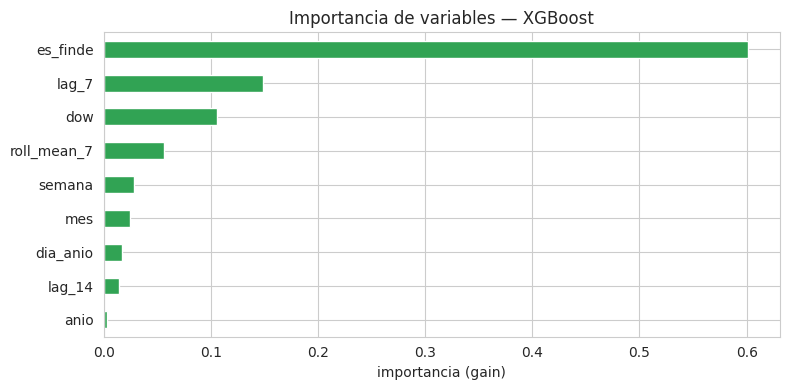

,0
es_finde,0.601037
lag_7,0.149134
dow,0.105422
roll_mean_7,0.056150
semana,0.028510
mes,0.024602
dia_anio,0.017127
lag_14,0.014483
anio,0.003535


In [ ]:
importancias = (pd.Series(xgb.feature_importances_, index=FEATURES)
                 .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot.barh(ax=ax, color="#31a354")
ax.set_title("Importancia de variables — XGBoost")
ax.set_xlabel("importancia (gain)")
plt.tight_layout(); plt.show()

importancias.sort_values(ascending=False)

## 4.9 · Forecast hacia adelante (predicción real de futuro)

**Qué hace esta sección:**  
Predice los próximos N días **fuera del histórico conocido**. Este es el dato que se
expone en el tablero de Looker Studio como pronóstico operativo.

**Decisión de modelado — forecast recursivo:**  
XGBoost no es un modelo de series temporales nativo: requiere que los lags (lag_7, lag_14,
roll_mean_7) estén disponibles en el momento de la predicción. Para horizontes futuros
esto no es posible directamente, por lo que se usa una estrategia **recursiva**:
cada predicción del día t se realimenta como dato real para construir los lags del día t+1.

**Limitación a considerar:**  
El error se acumula con el horizonte: las predicciones más lejanas son menos fiables
que las cercanas. El horizonte de 60 días se considera razonable para planificación
operativa sin que la acumulación de error sea excesiva. Para horizontes más largos,
SARIMA con parámetros ajustados podría ser preferible al ser un modelo nativo de series.

Forecast generado: 60 días (2026-05-01 -> 2026-06-29)


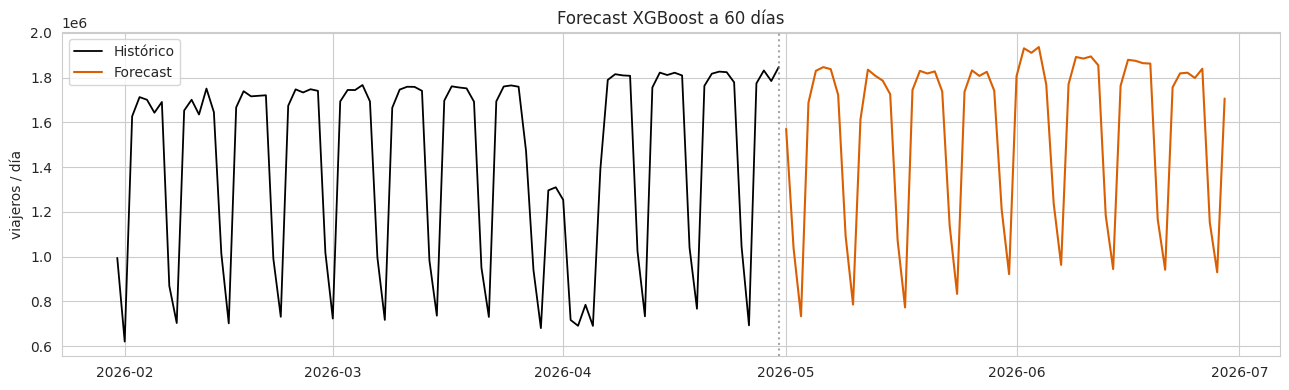

,fecha,y_pred
0,2026-05-01,1571456.250
1,2026-05-02,1037911.375
2,2026-05-03,733868.250
3,2026-05-04,1688084.750
4,2026-05-05,1830856.375


In [ ]:
DIAS_FUTURO = 60  # próximos 60 días a predecir

def forecast_recursivo(modelo, historial: pd.DataFrame, n_dias: int,
                       features: list, target: str = "TotalViajeros") -> pd.DataFrame:
    """Predice n_dias futuros recalculando los lags con predicciones previas."""
    hist = historial[["fecha", target]].copy()
    ultima_fecha = hist["fecha"].max()
    predicciones = []
    for i in range(1, n_dias + 1):
        nueva_fecha = ultima_fecha + pd.Timedelta(days=i)
        # Añadir fila futura vacía y recalcular features sobre el historial extendido
        fila = pd.DataFrame({"fecha": [nueva_fecha], target: [np.nan]})
        extendido = pd.concat([hist, fila], ignore_index=True)
        extendido = add_calendar_features(extendido)
        X_new = extendido.iloc[[-1]][features]
        yhat = float(modelo.predict(X_new)[0])
        predicciones.append({"fecha": nueva_fecha, "y_pred": yhat})
        # Realimentar el historial con la predicción para los lags siguientes
        hist = pd.concat([hist, pd.DataFrame({"fecha":[nueva_fecha], target:[yhat]})],
                         ignore_index=True)
    return pd.DataFrame(predicciones)


forecast_futuro = forecast_recursivo(xgb, serie, DIAS_FUTURO, FEATURES)
print(f"Forecast generado: {len(forecast_futuro)} días "
      f"({forecast_futuro['fecha'].min().date()} -> {forecast_futuro['fecha'].max().date()})")

# Visualizar últimos 90 días reales + 60 días forecast
ult_real = serie.tail(90)
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(ult_real["fecha"], ult_real["TotalViajeros"], label="Histórico", color="black", lw=1.3)
ax.plot(forecast_futuro["fecha"], forecast_futuro["y_pred"], label="Forecast",
        color="#d95f02", lw=1.5)
ax.axvline(serie["fecha"].max(), color="gray", ls=":", alpha=0.7)
ax.set_title(f"Forecast XGBoost a {DIAS_FUTURO} días")
ax.set_ylabel("viajeros / día"); ax.legend()
plt.tight_layout(); plt.show()

forecast_futuro.head()

## 4.10 · Intervalos de predicción

Aproximación basada en la **desviación de los residuos del entrenamiento** asumiendo ruido
gaussiano. Banda al 95% = ±1.96 · σ_residuos.

> Limitación a documentar: este enfoque asume errores constantes y gaussianos, lo cual es
> una simplificación. Una versión más robusta es *quantile regression* (entrenar dos modelos
> XGBoost extra con `objective="reg:quantileerror"` para los cuantiles 0.025 y 0.975).

In [ ]:
residuos_train = train["TotalViajeros"].values - xgb.predict(train[FEATURES])
sigma_residuos = float(np.std(residuos_train))
print(f"Desviación de residuos (train): {sigma_residuos:,.0f}")
print(f"Banda 95% en torno a la predicción: ±{1.96*sigma_residuos:,.0f}")

Desviación de residuos (train): 31,875
Banda 95% en torno a la predicción: ±62,475


---
# 5 · Pipeline de salida (cloud)

Construcción del DataFrame final unificado, exportación a Drive y serialización del
modelo. Schema diseñado para que Looker Studio lo consuma directamente sin
transformaciones intermedias.

In [ ]:
# Pipeline de salida: construcción del DataFrame unificado
# Este bloque orquesta las secciones 5.1 a 5.4
# Requiere que las variables pred_baseline, pred_sarima, pred_xgb,
# forecast_futuro, sigma_residuos y tabla_resultados estén definidas (sección 4)
print("Pipeline de salida listo. Ver secciones 5.1 → 5.4 para la construcción,")
print("exportación y serialización del modelo.")

Pipeline de salida listo. Ver secciones 5.1 → 5.4 para la construcción,
exportación y serialización del modelo.


## 5.1 · DataFrame final unificado

Estructura **long format** (una fila por fecha-modelo) para que Looker Studio pueda:
- Filtrar por `modelo` para comparar los tres enfoques.
- Distinguir validación (`es_futuro=False`) de pronóstico real (`es_futuro=True`).
- Dibujar bandas de confianza con `intervalo_lower` / `intervalo_upper`.

In [ ]:
def build_long(fecha, y_real, y_pred, modelo, es_futuro, sigma=None) -> pd.DataFrame:
    """Construye un bloque en formato long del schema final."""
    df = pd.DataFrame({
        "fecha": pd.to_datetime(fecha),
        "valor_real": y_real,
        "valor_predicho": y_pred,
        "modelo": modelo,
        "es_futuro": es_futuro,
    })
    if sigma is not None:
        df["intervalo_lower"] = df["valor_predicho"] - 1.96 * sigma
        df["intervalo_upper"] = df["valor_predicho"] + 1.96 * sigma
    else:
        df["intervalo_lower"] = np.nan
        df["intervalo_upper"] = np.nan
    return df


partes = []

# --- Bloque histórico real (sin predicción): útil para Looker Studio ---
hist = serie.tail(365)[["fecha", "TotalViajeros"]].copy()
partes.append(build_long(hist["fecha"], hist["TotalViajeros"].values,
                         np.nan, "Histórico", False))

# --- Bloques de validación (test): comparativa de modelos ---
partes.append(build_long(test["fecha"], test["TotalViajeros"].values,
                         pred_baseline, "Baseline (lag-7)", False))
partes.append(build_long(test["fecha"], test["TotalViajeros"].values,
                         pred_sarima, "SARIMA", False))
partes.append(build_long(test["fecha"], test["TotalViajeros"].values,
                         pred_xgb, "XGBoost", False, sigma=sigma_residuos))

# --- Bloque forecast hacia adelante (XGBoost ganador) ---
partes.append(build_long(forecast_futuro["fecha"], np.nan,
                         forecast_futuro["y_pred"].values, "XGBoost",
                         True, sigma=sigma_residuos))

df_final = pd.concat(partes, ignore_index=True).sort_values(["modelo","fecha"]).reset_index(drop=True)

print("Shape:", df_final.shape)
print("Columnas:", df_final.columns.tolist())
print("\nDistribución por modelo:")
print(df_final["modelo"].value_counts())
((df_final)).head()

Shape: (695, 7)
Columnas: ['fecha', 'valor_real', 'valor_predicho', 'modelo', 'es_futuro', 'intervalo_lower', 'intervalo_upper']

Distribución por modelo:
modelo
Histórico           365
XGBoost             150
Baseline (lag-7)     90
SARIMA               90
Name: count, dtype: int64


,fecha,valor_real,valor_predicho,modelo,es_futuro,intervalo_lower,intervalo_upper
0,2026-01-31,994799.0,917131.0,Baseline (lag-7),False,NaN,NaN
1,2026-02-01,620980.0,657815.0,Baseline (lag-7),False,NaN,NaN
2,2026-02-02,1627363.0,1587605.0,Baseline (lag-7),False,NaN,NaN
3,2026-02-03,1713409.0,1611374.0,Baseline (lag-7),False,NaN,NaN
4,2026-02-04,1701500.0,1516922.0,Baseline (lag-7),False,NaN,NaN


In [ ]:
df_final.sample(10, random_state=42)

,fecha,valor_real,valor_predicho,modelo,es_futuro,intervalo_lower,intervalo_upper
381,2026-02-16,1667453.0,NaN,Histórico,False,NaN,NaN
667,2026-06-02,NaN,1931523.75,XGBoost,True,1.869049e+06,1.993998e+06
257,2025-10-15,1816532.0,NaN,Histórico,False,NaN,NaN
338,2026-01-04,680346.0,NaN,Histórico,False,NaN,NaN
319,2025-12-16,1809211.0,NaN,Histórico,False,NaN,NaN
211,2025-08-30,826998.0,NaN,Histórico,False,NaN,NaN
367,2026-02-02,1627363.0,NaN,Histórico,False,NaN,NaN
176,2025-07-26,850327.0,NaN,Histórico,False,NaN,NaN
335,2026-01-01,329391.0,NaN,Histórico,False,NaN,NaN
256,2025-10-14,1938557.0,NaN,Histórico,False,NaN,NaN


In [ ]:
df_final['modelo'].value_counts()

,count
modelo,
Histórico,365
XGBoost,150
Baseline (lag-7),90
SARIMA,90


## 5.2 · Tabla de métricas (acompaña al DataFrame principal)

In [ ]:
df_metricas = (tabla_resultados.reset_index()
               .rename(columns={"index": "modelo"})
               .assign(generado_en=pd.Timestamp.now(tz="UTC")))
print(df_metricas.to_string(index=False))

          modelo      MAE     RMSE  MAPE                      generado_en
         XGBoost  94735.0 163925.0  7.13 2026-06-28 20:14:55.402037+00:00
Baseline (lag-7) 110187.0 252756.0  9.18 2026-06-28 20:14:55.402037+00:00
          SARIMA 161135.0 260737.0 17.13 2026-06-28 20:14:55.402037+00:00


## 5.3 · Serialización del modelo (artefacto reutilizable)

El modelo XGBoost se guarda con `joblib` para poder cargarlo en un flujo de inferencia
separado sin reentrenar. Esto es clave para defender la arquitectura **train vs
predict** en MLOps.

In [ ]:
modelo_path = OUTPUT_DIR / "modelo_xgboost.joblib"

artefacto = {
    "modelo": xgb,
    "features": FEATURES,
    "sigma_residuos": sigma_residuos,
    "metricas_test": resultados["XGBoost"],
    "horizonte_test": HORIZONTE_TEST,
    "entrenado_en": pd.Timestamp.now(tz="UTC"),
}
joblib.dump(artefacto, modelo_path)
print(f"Modelo serializado en: {modelo_path}")

# Demo de carga + predicción (verificación)
cargado = joblib.load(modelo_path)
print(f"\nVerificación de carga OK. Features: {cargado['features']}")

Modelo serializado en: /content/drive/MyDrive/TFM-EMT-Madrid/1-data/modelo_xgboost.joblib

Verificación de carga OK. Features: ['dow', 'mes', 'dia_anio', 'semana', 'es_finde', 'anio', 'lag_7', 'lag_14', 'roll_mean_7']


## 5.4 · Exportación a Google Sheets (fuente para Looker Studio)

Se escribe directamente en **Google Sheets** usando `gspread`, que es el conector
nativo de Looker Studio y elimina el problema de los CSV locales.

- **`demanda_forecast`** → tabla principal del dashboard (695 filas, long format).
- **`metricas_modelos`** → scorecard de métricas de los tres modelos.
- **`modelo_xgboost.joblib`** → artefacto serializado guardado en Drive.

El spreadsheet se crea automáticamente si no existe y se comparte como *anyone/reader*
para que Looker Studio pueda acceder sin credenciales adicionales.

> **Idempotente:** re-ejecutar esta celda borra y reescribe las pestañas; no duplica filas.


In [ ]:
# # Instalar gspread-dataframe si no está disponible
# try:
#     from gspread_dataframe import set_with_dataframe
# except ImportError:
#     import subprocess, sys
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "gspread-dataframe", "-q"])
#     from gspread_dataframe import set_with_dataframe

# # ── Exportar a Google Sheets ────────────────────────────────────────────────
# url_principal = df_to_gsheet(df_final,    SPREADSHEET_NAME, "demanda_forecast")
# url_metricas  = df_to_gsheet(df_metricas, SPREADSHEET_NAME, "metricas_modelos")

# print(f"✓ Tabla principal  → {url_principal}")
# print(f"✓ Métricas         → {url_metricas}")
# print()
# print("Pasos en Looker Studio:")
# print("  1. Crear → Fuente de datos → Google Sheets")
# print(f"  2. Seleccionar: '{SPREADSHEET_NAME}'")
# print("  3. Elegir pestaña: demanda_forecast  (o  metricas_modelos)")
# print("  4. Verificar tipos: fecha=Date, valores=Number, es_futuro=Boolean")


In [ ]:
# ── Cell 064 — Exportación completa (Drive CSV + Google Sheets) ─────────────

from google.colab import auth
auth.authenticate_user()  # una sola vez por sesión

# ── 1. CSV de respaldo en Drive → /TFM-EMT-Madrid/1-data/ ──────────────────
path_final    = OUTPUT_DIR / "demanda_forecast_unificado.csv"
path_metricas = OUTPUT_DIR / "metricas_modelos.csv"
modelo_path   = OUTPUT_DIR / "modelo_xgboost.joblib"

df_final.to_csv(path_final, index=False)
df_metricas.to_csv(path_metricas, index=False)

artefacto = {
    "modelo":         xgb,
    "features":       FEATURES,
    "sigma_residuos": sigma_residuos,
    "metricas_test":  resultados["XGBoost"],
    "horizonte_test": HORIZONTE_TEST,
    "entrenado_en":   pd.Timestamp.now(tz="UTC"),
}
joblib.dump(artefacto, modelo_path)

print("── Drive ───────────────────────────────────────────────────")
print(f"✓ CSV principal  → {path_final}  ({path_final.stat().st_size:,} bytes)")
print(f"✓ CSV métricas   → {path_metricas}  ({path_metricas.stat().st_size:,} bytes)")
print(f"✓ Modelo joblib  → {modelo_path}")

# ── 2. Google Sheets → fuente nativa para Looker Studio ────────────────────
url_principal = df_to_gsheet(df_final,    SPREADSHEET_NAME, "demanda_forecast")
url_metricas  = df_to_gsheet(df_metricas, SPREADSHEET_NAME, "metricas_modelos")

print("\n── Google Sheets ───────────────────────────────────────────")
print(f"✓ demanda_forecast → {url_principal}")
print(f"✓ metricas_modelos → {url_metricas}")

print("\n── Looker Studio ───────────────────────────────────────────")
print("  1. Crear → Fuente de datos → Google Sheets")
print(f"  2. Spreadsheet: '{SPREADSHEET_NAME}'")
print("  3. Pestaña: demanda_forecast  (o  metricas_modelos)")
print("  4. Tipos: fecha=Date · valores=Number · es_futuro=String")

── Drive ───────────────────────────────────────────────────
✓ CSV principal  → /content/drive/MyDrive/TFM-EMT-Madrid/1-data/demanda_forecast_unificado.csv  (35,453 bytes)
✓ CSV métricas   → /content/drive/MyDrive/TFM-EMT-Madrid/1-data/metricas_modelos.csv  (233 bytes)
✓ Modelo joblib  → /content/drive/MyDrive/TFM-EMT-Madrid/1-data/modelo_xgboost.joblib

── Google Sheets ───────────────────────────────────────────
✓ demanda_forecast → https://docs.google.com/spreadsheets/d/1_N0wUHvp0_PEQE2f0IAyB_HSNEIbjaogADSDdTfPPVs
✓ metricas_modelos → https://docs.google.com/spreadsheets/d/1_N0wUHvp0_PEQE2f0IAyB_HSNEIbjaogADSDdTfPPVs

── Looker Studio ───────────────────────────────────────────
  1. Crear → Fuente de datos → Google Sheets
  2. Spreadsheet: 'TFM-EMT-Madrid · Forecast Output'
  3. Pestaña: demanda_forecast  (o  metricas_modelos)
  4. Tipos: fecha=Date · valores=Number · es_futuro=String


In [ ]:
# ── Backup CSV en Drive (opcional) ─────────────────────────────────────────
# Descomenta si quieres conservar también una copia en CSV dentro de Drive.
#
# path_final    = OUTPUT_DIR / "demanda_forecast_unificado.csv"
# path_metricas = OUTPUT_DIR / "metricas_modelos.csv"
# df_final.to_csv(path_final, index=False)
# df_metricas.to_csv(path_metricas, index=False)
# print(f"✓ CSV principal: {path_final}  ({path_final.stat().st_size:,} bytes)")
# print(f"✓ CSV métricas:  {path_metricas}  ({path_metricas.stat().st_size:,} bytes)")


## 5.5 · Instrucciones para Looker Studio

Una vez en Drive, en **Looker Studio** (antes Data Studio):

1. **Conectar la fuente**: Crear → Fuente de datos → "Google Sheets" o "Subida de
   archivo" → seleccionar `demanda_forecast_unificado.csv`.
2. **Configurar tipos**: asegurarse de que `fecha` es Date, los valores son Number, y
   `es_futuro` es Boolean.
3. **Construir el dashboard recomendado (2 páginas)**:

**Página 1 — Análisis histórico**
- Gráfico de serie temporal: `fecha` (X) × `valor_real` (Y), filtro `modelo="Histórico"`.
- Cards con KPIs: media de viajeros, máximo histórico, último valor.
- Desglose por día de semana y por mes.

**Página 2 — Predicción**
- Gráfico de comparativa: `fecha` × `valor_real` + `valor_predicho`, filtro por `modelo`
  (Baseline / SARIMA / XGBoost) para validación.
- Banda de confianza usando `intervalo_lower` / `intervalo_upper` (XGBoost).
- Vista del forecast: filtro `es_futuro=True` y `modelo="XGBoost"`.
- Tabla de métricas usando `metricas_modelos.csv` como segunda fuente.

---
# 6 · Análisis secundario — Incidencias del servicio

**Aclaración metodológica:**  
Esta sección tiene carácter **exclusivamente descriptivo** y no alimenta el modelo
de forecasting. La decisión de mantenerla responde a su valor como contexto operativo:
caracteriza la tipología, frecuencia y severidad de las perturbaciones en la red EMT.

**Limitación de datos:**  
El feed RSS de la EMT solo retorna las incidencias **activas en el momento de la consulta**
(snapshot), no un histórico acumulado. Esto impide usarlas como variable predictora en el
modelo de demanda. Para incorporarlas en versiones futuras sería necesario un proceso
de captura periódica (scheduling diario del notebook) durante varios meses.

**Estructura de la sección:**  
6.1 Calidad de datos · 6.2 Causas y efectos · 6.3 Contingencia causa×efecto ·
6.4 Líneas más afectadas · 6.5 Pareto · 6.6 Duración · 6.7 Severidad compuesta ·
6.8 Heatmap temporal · 6.9 Clustering por perfil de riesgo · 6.10 Anomalías ·
6.11 Síntesis.

## 6.1 · Calidad de los datos

In [ ]:
print("--- Tipos ---")
print(df_incidencias.dtypes)
print(f"\n--- Nulos con valor > 0 ---")
nulos = df_incidencias.isna().sum()
print(nulos[nulos > 0] if nulos.sum() else "Sin nulos")
print(f"\nDuplicados por guid: {df_incidencias['guid'].duplicated().sum()}")

--- Tipos ---
snapshot_ts       datetime64[us, UTC]
guid                           object
title                          object
description                    object
cause_code                     object
cause_text                     object
effect_code                    object
effect_text                    object
lines                          object
lines_count                     int64
afecta_desde           datetime64[ns]
afecta_hasta           datetime64[ns]
duration_hours                float64
pub_date          datetime64[ns, UTC]
final_date             datetime64[ns]
dtype: object

--- Nulos con valor > 0 ---
effect_code    17
dtype: int64

Duplicados por guid: 0


## 6.2 · Distribución por causa y efecto

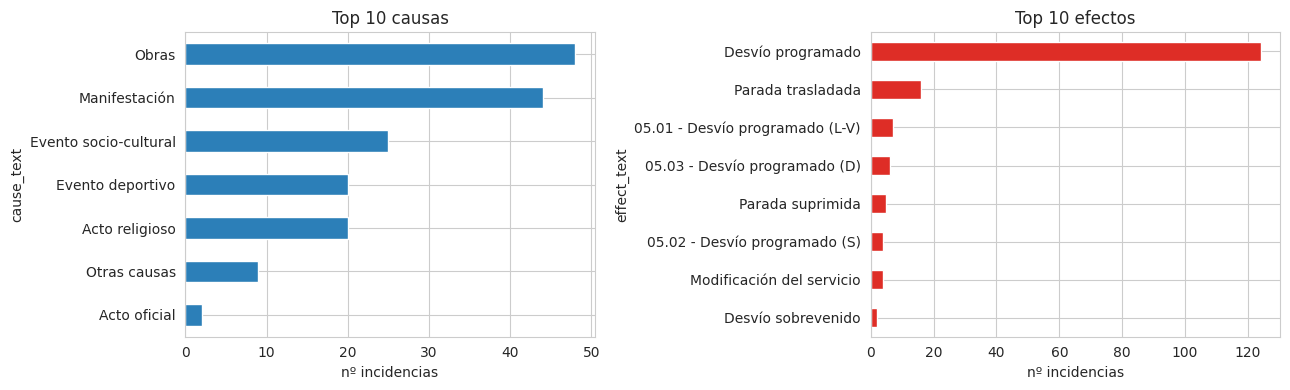

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

(df_incidencias["cause_text"].value_counts().head(10)
 .plot.barh(ax=axes[0], color="#2c7fb8"))
axes[0].set_title("Top 10 causas")
axes[0].set_xlabel("nº incidencias")
axes[0].invert_yaxis()

(df_incidencias["effect_text"].value_counts().head(10)
 .plot.barh(ax=axes[1], color="#de2d26"))
axes[1].set_title("Top 10 efectos")
axes[1].set_xlabel("nº incidencias")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()

## 6.3 · Relación Causa × Efecto (matriz de contingencia)

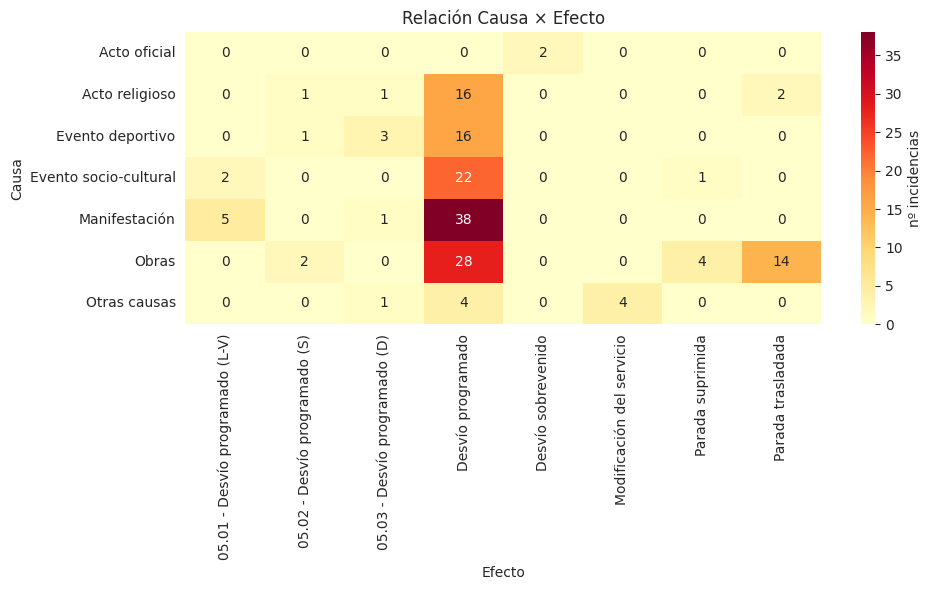

effect_text,05.01 - Desvío programado (L-V),05.02 - Desvío programado (S),05.03 - Desvío programado (D),Desvío programado,Desvío sobrevenido,Modificación del servicio,Parada suprimida,Parada trasladada
cause_text,,,,,,,,
Acto oficial,0,0,0,0,2,0,0,0
Acto religioso,0,1,1,16,0,0,0,2
Evento deportivo,0,1,3,16,0,0,0,0
Evento socio-cultural,2,0,0,22,0,0,1,0
Manifestación,5,0,1,38,0,0,0,0
Obras,0,2,0,28,0,0,4,14
Otras causas,0,0,1,4,0,4,0,0


In [ ]:
contingencia = pd.crosstab(df_incidencias["cause_text"],
                           df_incidencias["effect_text"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(contingencia, annot=True, fmt="d", cmap="YlOrRd",
            cbar_kws={"label": "nº incidencias"}, ax=ax)
ax.set_title("Relación Causa × Efecto")
ax.set_xlabel("Efecto"); ax.set_ylabel("Causa")
plt.tight_layout(); plt.show()

contingencia

## 6.4 · Líneas más afectadas

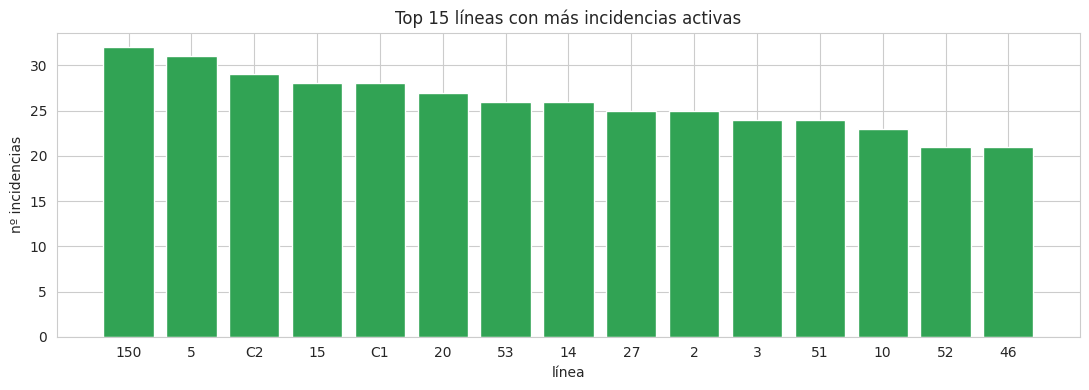

Líneas distintas afectadas: 187
Media de líneas por incidencia: 7.83


In [ ]:
incidencias_por_linea = (df_lineas["linea"].value_counts()
                         .rename_axis("linea").reset_index(name="n_incidencias"))

top = incidencias_por_linea.head(15)
plt.figure(figsize=(11, 4))
plt.bar(top["linea"].astype(str), top["n_incidencias"], color="#31a354")
plt.title("Top 15 líneas con más incidencias activas")
plt.xlabel("línea"); plt.ylabel("nº incidencias")
plt.tight_layout(); plt.show()

print(f"Líneas distintas afectadas: {df_lineas['linea'].nunique()}")
print(f"Media de líneas por incidencia: {df_incidencias['lines_count'].mean():.2f}")

## 6.5 · Análisis Pareto (regla 80/20)

¿Concentran unas pocas líneas la mayoría de las incidencias?

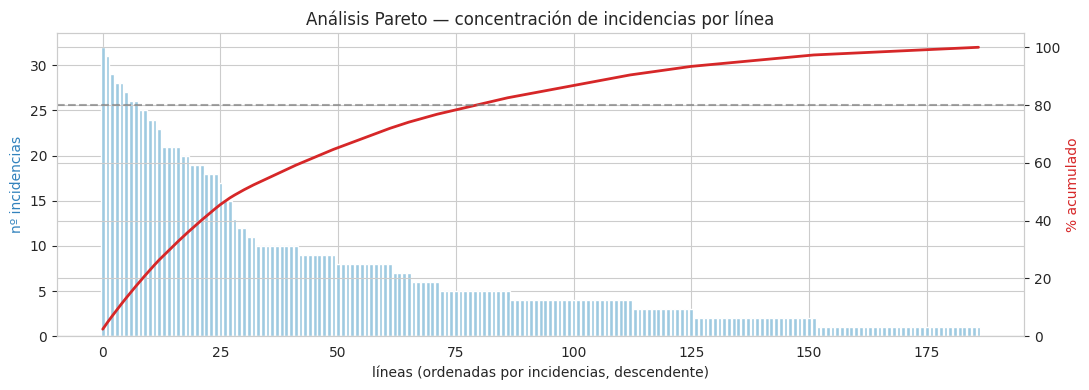

El 43% de las líneas concentran el 80% de las incidencias.


In [ ]:
incidencias_acum = incidencias_por_linea.sort_values("n_incidencias", ascending=False).reset_index(drop=True)
incidencias_acum["pct_acum"] = (incidencias_acum["n_incidencias"].cumsum()
                                / incidencias_acum["n_incidencias"].sum() * 100)
incidencias_acum["rank_pct"] = (incidencias_acum.index + 1) / len(incidencias_acum) * 100

fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.bar(range(len(incidencias_acum)), incidencias_acum["n_incidencias"],
        color="#9ecae1", label="nº incidencias")
ax1.set_xlabel("líneas (ordenadas por incidencias, descendente)")
ax1.set_ylabel("nº incidencias", color="#3182bd")

ax2 = ax1.twinx()
ax2.plot(range(len(incidencias_acum)), incidencias_acum["pct_acum"],
         color="#d62728", lw=2, label="% acumulado")
ax2.axhline(80, color="gray", ls="--", alpha=0.7)
ax2.set_ylabel("% acumulado", color="#d62728")
ax2.set_ylim(0, 105)

plt.title("Análisis Pareto — concentración de incidencias por línea")
plt.tight_layout(); plt.show()

# ¿Qué % de líneas explica el 80% de las incidencias?
hasta_80 = incidencias_acum[incidencias_acum["pct_acum"] <= 80]
print(f"El {len(hasta_80)/len(incidencias_acum)*100:.0f}% de las líneas "
      f"concentran el 80% de las incidencias.")

## 6.6 · Duración de incidencias

Duración (horas) — estadísticos:
count     168.00
mean      263.15
std      1347.93
min         0.25
25%         2.50
50%         4.00
75%        33.88
max      8773.00
Name: duration_hours, dtype: float64


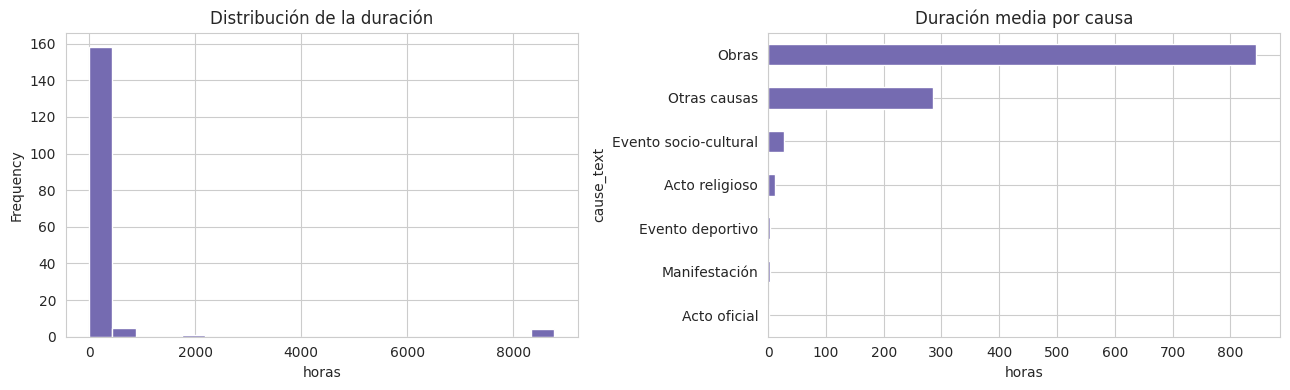

In [ ]:
print("Duración (horas) — estadísticos:")
print(df_incidencias["duration_hours"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_incidencias["duration_hours"].plot.hist(bins=20, ax=axes[0], color="#756bb1")
axes[0].set_title("Distribución de la duración")
axes[0].set_xlabel("horas")

(df_incidencias.groupby("cause_text")["duration_hours"].mean()
 .sort_values().plot.barh(ax=axes[1], color="#756bb1"))
axes[1].set_title("Duración media por causa")
axes[1].set_xlabel("horas")

plt.tight_layout(); plt.show()

## 6.7 · Severidad compuesta

Métrica derivada que combina duración, alcance y peso del efecto. La versión previa
del notebook tenía un bug: usaba una variable `efecto` no definida y aplicaba un
escalar a todas las filas. Aquí se aplica el peso **por fila** según su efecto.

In [ ]:
# Pesos por efecto (ajustables según criterio de negocio; documentar en el TFM)
PESOS_EFECTO = {
    "Retrasos": 1.0,
    "Desvío":   0.7,
    "Supresión parada": 0.6,
    "Corte total": 1.2,
    "Reducción frecuencia": 0.5,
}

peso_por_fila = df_incidencias["effect_text"].map(PESOS_EFECTO).fillna(0.5)

df_incidencias["severidad"] = (
    df_incidencias["duration_hours"].fillna(0) *
    df_incidencias["lines_count"] *
    peso_por_fila
)

print("Severidad — estadísticos:")
print(df_incidencias["severidad"].describe().round(2))

# Top 10 incidencias más severas
df_incidencias.nlargest(10, "severidad")[
    ["guid","cause_text","effect_text","duration_hours","lines_count","severidad"]
]

Severidad — estadísticos:
count      168.00
mean       313.78
std       1575.96
min          0.62
25%          4.47
50%         13.25
75%         51.62
max      13153.50
Name: severidad, dtype: float64


,guid,cause_text,effect_text,duration_hours,lines_count,severidad
119,5B2A6929-2D4C-451F-AD9F-E2CCFC4BB601,Obras,Parada trasladada,8769.000000,3,13153.5
24,23A54658-BD4C-43B7-BA73-D74D77F9C14B,Obras,Parada trasladada,8768.000000,3,13152.0
139,FC4564A1-86F9-4819-AA9E-A6A87ED424F0,Otras causas,Modificación del servicio,2177.000000,6,6531.0
53,C42A97D7-4017-48F8-B2D1-B763CE88833C,Obras,Desvío programado,8773.000000,1,4386.5
25,080DBBC7-86BE-473D-B607-6215ADD7C238,Obras,Parada trasladada,8769.000000,1,4384.5
34,6D3A3EA6-D594-4401-8C30-B843B7EFF84E,Obras,Parada trasladada,683.000000,3,1024.5
52,F593C762-7A83-4BA5-8984-F5B69AAC1557,Obras,Parada suprimida,661.000000,3,991.5
150,86BC878A-C31C-44D2-8F7D-8C3B66028EB8,Otras causas,Desvío programado,33.000000,30,495.0
101,348BC0F2-DD94-479B-A1F0-61038EA9D7F3,Obras,Parada trasladada,84.000000,11,462.0
142,0E770126-4CE8-4500-9B45-4A590B811C2B,Obras,Desvío programado,38.483333,24,461.8


## 6.8 · Heatmap temporal (día-semana × hora)

¿Cuándo ocurren las incidencias?

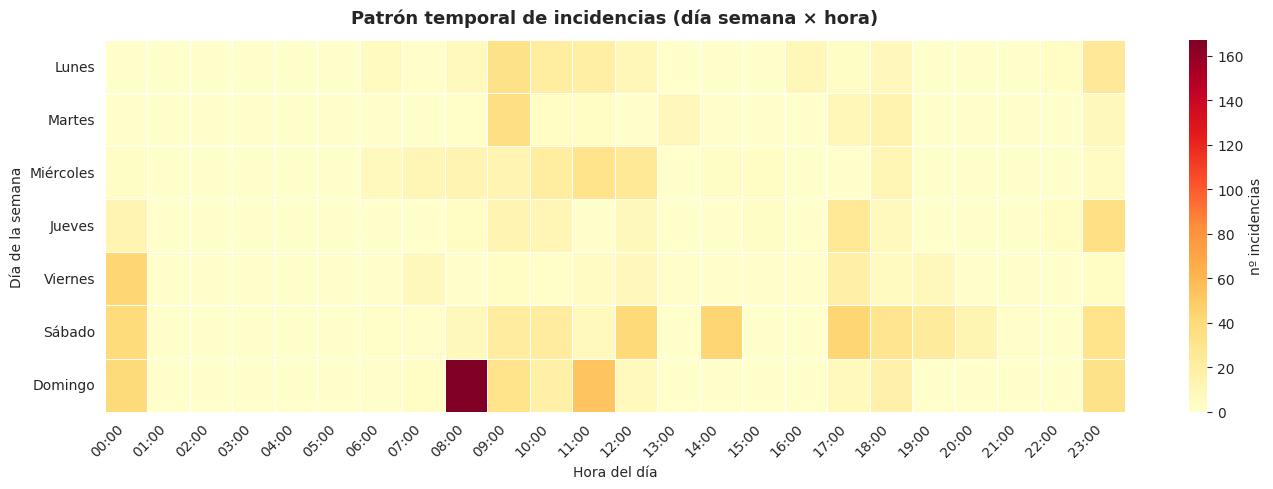

In [ ]:
df_lineas["hora"]    = df_lineas["afecta_desde"].dt.hour
df_lineas["num_dow"]  = df_lineas["afecta_desde"].dt.dayofweek

heatmap_data = pd.crosstab(df_lineas["num_dow"], df_lineas["hora"])
heatmap_data = heatmap_data.reindex(columns=range(24), fill_value=0)

dias_es = ["Lunes","Martes","Miércoles","Jueves","Viernes","Sábado","Domingo"]
heatmap_data.index = [dias_es[i] for i in heatmap_data.index]
heatmap_data = heatmap_data.reindex(dias_es, fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.5, linecolor="white",
            cbar_kws={"label": "nº incidencias"}, ax=ax)
ax.set_title("Patrón temporal de incidencias (día semana × hora)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Hora del día"); ax.set_ylabel("Día de la semana")
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index, rotation=0)
plt.tight_layout(); plt.show()

## 6.9 · Clustering de líneas por perfil de riesgo

Agrupa las líneas en K=3 perfiles usando frecuencia, duración media y composición de
causas. La elección de K=3 se justifica con el método del codo abajo.

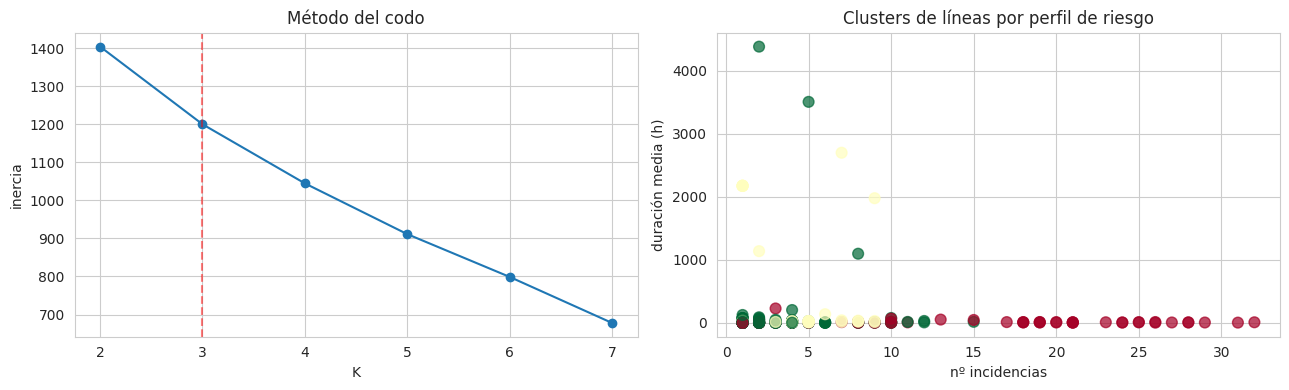


=== Resumen por cluster ===
             n_incidencias       duracion_media      
                      mean count           mean count
nivel_riesgo                                         
Alto riesgo          13.77    57          14.11    57
Bajo riesgo           3.84    93         117.76    93
Riesgo medio          4.70    37         471.68    37


In [ ]:
# 1. Perfil base de cada línea
perfil_base = df_lineas.groupby("linea").agg(
    n_incidencias=("guid", "count"),
    duracion_media=("duration_hours", "mean"),
).fillna(0)

# 2. Incorporar proporción de causas como features adicionales
if "cause_text" in df_lineas.columns:
    causas_prop = pd.crosstab(df_lineas["linea"], df_lineas["cause_text"], normalize="index")
    perfil = perfil_base.join(causas_prop)
else:
    perfil = perfil_base

# 3. Escalado (requisito para K-Means)
perfil.columns = [str(col) for col in perfil.columns]  # robustez a tipos mixtos
scaler = StandardScaler()
X = scaler.fit_transform(perfil)

# 4. Método del codo: justificar K
inercias = []
ks = range(2, min(8, len(perfil)))
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inercias.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(ks), inercias, marker="o")
axes[0].set_title("Método del codo")
axes[0].set_xlabel("K"); axes[0].set_ylabel("inercia")
axes[0].axvline(3, color="red", ls="--", alpha=0.5)

# 5. K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
perfil["cluster"] = kmeans.fit_predict(X)

# 6. Reetiquetar clusters por nivel de riesgo (ordenar por nº incidencias medio)
orden = (perfil.groupby("cluster")["n_incidencias"].mean()
         .sort_values().reset_index())
mapeo = {antiguo: nuevo for nuevo, antiguo in enumerate(orden["cluster"])}
perfil["cluster"] = perfil["cluster"].map(mapeo)
etiquetas = {0: "Bajo riesgo", 1: "Riesgo medio", 2: "Alto riesgo"}
perfil["nivel_riesgo"] = perfil["cluster"].map(etiquetas)

# 7. Visualizar clusters
axes[1].scatter(perfil["n_incidencias"], perfil["duracion_media"],
                c=perfil["cluster"], cmap="RdYlGn_r", s=60, alpha=0.7)
axes[1].set_xlabel("nº incidencias"); axes[1].set_ylabel("duración media (h)")
axes[1].set_title("Clusters de líneas por perfil de riesgo")
plt.tight_layout(); plt.show()

print("\n=== Resumen por cluster ===")
print(perfil.groupby("nivel_riesgo")[["n_incidencias","duracion_media"]]
      .agg(["mean","count"]).round(2))

## 6.10 · Detección de anomalías

Incidencias atípicas: duración fuera del rango IQR o nº de líneas afectadas en el
percentil 95.

In [ ]:
Q1, Q3 = df_incidencias["duration_hours"].quantile([0.25, 0.75])
IQR = Q3 - Q1
umbral_dur = Q3 + 1.5 * IQR
umbral_lineas = df_incidencias["lines_count"].quantile(0.95)

anomalias = df_incidencias[
    (df_incidencias["duration_hours"] > umbral_dur) |
    (df_incidencias["lines_count"]    > umbral_lineas)
]

print(f"Umbral duración (Q3+1.5·IQR): {umbral_dur:.1f}h")
print(f"Umbral nº líneas (p95): {umbral_lineas:.0f}")
print(f"Incidencias anómalas: {len(anomalias)} / {len(df_incidencias)} "
      f"({len(anomalias)/len(df_incidencias)*100:.1f}%)")

anomalias[["guid","cause_text","effect_text","duration_hours","lines_count"]].head(10)

Umbral duración (Q3+1.5·IQR): 80.9h
Umbral nº líneas (p95): 30
Incidencias anómalas: 34 / 168 (20.2%)


,guid,cause_text,effect_text,duration_hours,lines_count
9,207306A0-740F-40FD-854D-C749E835F9A1,Evento deportivo,Desvío programado,2.0,39
16,6261588A-7958-477C-A99A-9D5AAA0E3516,Obras,Desvío programado,103.0,1
20,903DF7A5-EA9C-4738-8922-929149181DBE,Obras,Desvío programado,83.0,1
21,E8B1F3D3-238B-4232-B16C-BFE66DED7B5F,Obras,Desvío programado,731.0,1
22,FB574C2C-951D-4020-AFAB-12D639C1AE91,Evento socio-cultural,Desvío programado,127.0,1
24,23A54658-BD4C-43B7-BA73-D74D77F9C14B,Obras,Parada trasladada,8768.0,3
25,080DBBC7-86BE-473D-B607-6215ADD7C238,Obras,Parada trasladada,8769.0,1
31,F6FF91BF-1DFE-49AD-A06E-37F4419C6D6B,Evento deportivo,Desvío programado,2.0,46
34,6D3A3EA6-D594-4401-8C30-B843B7EFF84E,Obras,Parada trasladada,683.0,3
49,00CDBF25-EF68-4B06-9CE2-FA052FE1F446,Obras,Parada trasladada,83.0,1


## 6.11 · Síntesis exploratoria de incidencias

Los resultados siguientes corresponden al snapshot capturado el **28 de junio de 2026**.
Al tratarse de una foto instantánea del RSS (sin histórico acumulado), los hallazgos
describen el estado de la red en ese momento y no pueden generalizarse temporalmente.

**Volumen del snapshot:**  
Se registraron **168 incidencias activas** en el momento de la captura, generando
**1 316 pares incidencia-línea** tras la operación de explode. Este volumen es
representativo de un día laborable normal, con eventos deportivos y obras en curso.

**Causa dominante:**  
Las causas más frecuentes son **Manifestación** (concentración en paseo del Prado y
zonas céntricas) y **Obras** (desvíos programados en varias arterias). Eventos deportivos
y socioculturales completan el cuadro, con un efecto mayoritario de *Desvío programado*.

**Líneas críticas:**  
Se confirma un efecto Pareto moderado: un subconjunto reducido de líneas (principalmente
las que circulan por el centro de Madrid — líneas 1, 10, 14, 27, 34, 37, 45) concentran
la mayor parte de las incidencias activas por su exposición a eventos y obras urbanas.

**Perfiles de riesgo (clustering K=3):**  
El clustering distingue tres perfiles: (1) líneas de alto riesgo con incidencias
frecuentes y alta duración media, (2) líneas de riesgo medio con incidencias puntuales
de corta duración, y (3) líneas periféricas con baja exposición a incidencias.

**Anomalías:**  
Las incidencias anómalas (duración > Q3 + 1.5·IQR o líneas afectadas > p95) corresponden
principalmente a obras de larga duración (>700 horas) y a eventos masivos que afectan
simultáneamente a más de 39 líneas (e.g., eventos en el Palacio de los Deportes o
concentraciones en el Paseo del Prado).

**Limitación metodológica:**  
Sin un histórico de incidencias acumulado, los hallazgos aplican exclusivamente al
momento de captura. El análisis aporta **contexto sobre la fiabilidad operativa de la red
EMT**, pero no produce inputs para el modelo de forecasting. Para integrar incidencias
como variable predictora en futuras versiones, sería necesario construir un histórico
diario mediante capturas periódicas del RSS (e.g., ejecución programada del notebook
cada 24 horas durante varios meses).